In [35]:
import numpy as np
import pandas as pd
from matplotlib.lines import lineStyles
from plotly.io import show
from matplotlib import pyplot as plt
import seaborn as sns
from tabulate import tabulate
import vectorbt as vbt
import math

import optuna
from optuna.samplers import RandomSampler, TPESampler

from utils.KrakenHistoricalData import KrakenHistoricalData
from ggTrader.Signals import Signals


Setup

In [36]:
# setup
k = KrakenHistoricalData()

start_equity = 1000
symbols = ["BTC", "ETH", "LTC", "XRP"]
interval = "4h"
n_trials = 100
sampler = RandomSampler(seed=42)  # optional seed for reproducibility
# sampler = TPESampler(seed=42)

# Time Range
end = pd.to_datetime("2025-09-30").tz_localize('UTC')
# start = end - pd.Timedelta(days=30 * 6)
start = pd.to_datetime("2023-01-01").tz_localize('UTC')

# Indicator Params
params_default = {'sar_acceleration': 0.02,
                  'sar_maximum': 0.2,
                  'atr_multiplier': 3,
                  'adx_threshold': 25,
                  'adx_length': 14,
                  'atr_length': 14,  # atr multiplier for chandelier exit
                  'use_high': False,
                  }
params = params_default.copy()
# Fees
maker_fee = 0.0025
taker_fee = 0.004
transaction_fee = (maker_fee + taker_fee) / 2

data_df = k.get_ohlcv_df(symbols, interval=interval, start=start, end=end)

close = data_df.xs('close', axis=1, level=1)
high = data_df.xs('high', axis=1, level=1)
low = data_df.xs('low', axis=1, level=1)
open = data_df.xs('open', axis=1, level=1)


In [37]:
# ========= 2. Signal Data Comparison =========

def entry_signals(close,
                  high,
                  low,
                  adx_length: int = 14,
                  adx_threshold: int = 25,
                  sar_acceleration: float = 0.02,
                  sar_maximum: float = 0.2):
    sar_pandas_ta = vbt.pandas_ta('psar').run(high,
                                              low,
                                              close=close,
                                              acceleration=sar_acceleration,
                                              maximum=sar_maximum)
    sar_buy = sar_pandas_ta.psarl_below(close)

    adx_pandas_ta = vbt.pandas_ta('adx').run(high, low, close, length=adx_length)
    dmp_cross = adx_pandas_ta.dmp_above(adx_pandas_ta.dmn)
    adx_threshold_cross = adx_pandas_ta.adx_above(adx_threshold)
    adx_buy = dmp_cross & adx_threshold_cross

    return sar_buy & adx_buy


def stop_loss(entries, close, high, low, atr_length: int = 14, atr_multiplier: float = 3.0, use_high: bool = False):
    atr = vbt.pandas_ta('atr').run(high, low, close, length=atr_length)
    atrr = atr.atrr

    if use_high:
        entry_price = high.where(entries).ffill()
    else:
        entry_price = close.where(entries).ffill()

    # 3) 3x ATR stop distance as a fraction of entry
    #    (this is already positive: 3 * atr below entry)
    sl_stop = (atr_multiplier * atrr.values) / entry_price

    # Optional: if entry_price is NaN (no trade yet), keep NaN
    sl_stop = sl_stop.where(entry_price.notna())

    return sl_stop


def calc_signals(close: pd.DataFrame,
                 high: pd.DataFrame,
                 low: pd.DataFrame,
                 adx_length: int = 14,
                 adx_threshold: int = 25,
                 sar_acceleration: float = 0.02,
                 sar_maximum: float = 0.2,
                 atr_multiplier: float = 3.0,
                 atr_length: int = 14,
                 use_high: bool = False, ):
    entries = entry_signals(close, high, low, adx_length=adx_length, adx_threshold=adx_threshold,
                            sar_acceleration=sar_acceleration, sar_maximum=sar_maximum)
    exits = pd.DataFrame(False, index=entries.index, columns=entries.columns)
    sl_stop = stop_loss(entries, close, high, low, atr_multiplier=atr_multiplier, atr_length=atr_length,
                        use_high=use_high)
    return entries, exits, sl_stop





In [38]:
def reassign_columns_value(stats_df: pd.DataFrame, trial_num: int, level: int = 0):
    new_level_0 = stats_df.columns.levels[level].to_numpy().copy()
    new_level_0[:] = trial_num
    new_levels = [pd.Index(new_level_0), stats_df.columns.levels[1]]
    new_columns = stats_df.columns.set_levels(new_levels)

    # Assign back
    stats_df.columns = new_columns

    stats_df.columns = stats_df.columns.set_names(['id', 'symbol'])
    return stats_df


def assign_column_labels(stats_df: pd.DataFrame, labels: list):
    return stats_df.rename_axis(labels, axis=1)


def stats_df_to_wide(df: pd.DataFrame, trial_num: int):
    df = reassign_columns_value(df, trial_num, level=0)
    df = assign_column_labels(df, labels=['id', 'symbol'])
    df = df.T.reset_index()
    return convert_cols_to_numeric(df)


def convert_cols_to_numeric(df: pd.DataFrame):
    df['Start'] = pd.to_datetime(df['Start'], errors='coerce')
    df['End'] = pd.to_datetime(df['End'], errors='coerce')
    df['Period'] = pd.to_timedelta(df['Period'], errors='coerce')
    duration_str = 'Duration'
    for col in df.columns:
        # Skip columns we already converted to datetime/timedelta
        if col in ['Start', 'End', 'Period']:
            continue

        # Skip columns that are already numeric
        if pd.api.types.is_numeric_dtype(df[col]):
            continue
        if duration_str in col:
            df[col] = pd.to_timedelta(df[col], errors='coerce')
            continue
        # Try converting to numeric, catching exceptions
        try:
            df[col] = pd.to_numeric(df[col], errors='raise')
        except (ValueError, TypeError):
            # If conversion fails, leave the column as-is
            pass
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    return df

## Part 1: Initial Parameter Search

In [39]:
def objective(trial: optuna.Trial):
    # Entry
    params['adx_threshold'] = trial.suggest_int("adx_threshold", 0, 80, step=2)  #
    params['adx_length'] = trial.suggest_int("adx_length", 2, 50, step=2)
    params['sar_acceleration'] = trial.suggest_float("sar_acceleration", 0.02, 1.5, step=0.01)
    params['sar_maximum'] = trial.suggest_float("sar_maximum", 0.05, 1.7, step=0.01)

    # Exit
    params['atr_multiplier'] = trial.suggest_float("atr_multiplier", 1, 8, step=0.5)
    params['atr_length'] = trial.suggest_int("atr_length", 10, 50, step=2)
    params['use_high'] = trial.suggest_categorical("use_high", [True, False])

    entries, exits, sl_stop = calc_signals(close, high, low, **params)

    pf = vbt.Portfolio.from_signals(close,
                                    entries=entries,
                                    exits=exits,
                                    size=1,
                                    size_type='percent',
                                    direction='longonly',
                                    sl_stop=sl_stop,
                                    sl_trail=True,
                                    freq=interval,
                                    fees=transaction_fee,
                                    init_cash=start_equity,
                                    )
    stats_df = pd.DataFrame({col: pf[col].stats() for col in pf.wrapper.columns})
    sharpe = stats_df.loc["Sharpe Ratio"].mean()

    if sharpe is None or math.isnan(sharpe) or math.isinf(sharpe):
        raise optuna.exceptions.TrialPruned("Invalid objective (NaN/Inf).")
    wide = stats_df_to_wide(stats_df, trial.number)
    params_df = pd.DataFrame(params, index=wide.index)
    trial_summary = pd.concat([wide, params_df], axis=1)
    trials_summary_list.append(trial_summary)

    return sharpe


trials_summary_list = []

study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=n_trials)
trials_summary = pd.concat(trials_summary_list, axis=0).reset_index(drop=True)

[I 2025-11-09 17:00:42,127] A new study created in memory with name: no-name-e58f5782-4882-411f-95be-cce005e2cec7
[I 2025-11-09 17:00:42,768] Trial 0 finished with value: -0.12664507882276302 and parameters: {'adx_threshold': 30, 'adx_length': 48, 'sar_acceleration': 1.11, 'sar_maximum': 1.04, 'atr_multiplier': 2.0, 'atr_length': 16, 'use_high': False}. Best is trial 0 with value: -0.12664507882276302.
[I 2025-11-09 17:00:43,408] Trial 1 pruned. Invalid objective (NaN/Inf).
[I 2025-11-09 17:00:44,020] Trial 2 finished with value: 0.5060406992921199 and parameters: {'adx_threshold': 24, 'adx_length': 28, 'sar_acceleration': 0.66, 'sar_maximum': 0.53, 'atr_multiplier': 5.5, 'atr_length': 14, 'use_high': False}. Best is trial 2 with value: 0.5060406992921199.
[I 2025-11-09 17:00:45,112] Trial 3 finished with value: 0.3881276450910657 and parameters: {'adx_threshold': 36, 'adx_length': 40, 'sar_acceleration': 0.31, 'sar_maximum': 0.9, 'atr_multiplier': 5.0, 'atr_length': 10, 'use_high': Tr

Study Results

In [40]:
trials = study.trials_dataframe()
trials.sort_values('value', inplace=True, ascending=False)
trials.columns = trials.columns.str.removeprefix('params_')
trials.drop(['datetime_start', 'datetime_complete', 'duration', 'state'], axis=1, inplace=True)
print(tabulate(trials, headers='keys', tablefmt='github', showindex=False))



|   number |       value |   adx_length |   adx_threshold |   atr_length |   atr_multiplier |   sar_acceleration |   sar_maximum | use_high   |
|----------|-------------|--------------|-----------------|--------------|------------------|--------------------|---------------|------------|
|       86 |   1.24725   |           10 |              62 |           20 |              4.5 |               0.5  |          0.75 | False      |
|       18 |   1.17817   |            2 |              22 |           20 |              1   |               0.92 |          0.88 | True       |
|       47 |   1.17362   |            2 |              68 |           38 |              1.5 |               1.23 |          0.51 | False      |
|       46 |   1.17106   |            4 |              16 |           38 |              1.5 |               0.17 |          0.08 | False      |
|       83 |   1.16255   |            8 |               8 |           20 |              2   |               0.38 |          0.31 | False

In [41]:
parameters = list(params.keys())
performance = ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio', 'Profit Factor', 'Total Return [%]']

print(f"\nTop 10% Trials Summary:")
cols = parameters + performance
top_10_pct = int(n_trials * 0.1)
top_runs = trials_summary.sort_values('Sharpe Ratio', ascending=False).groupby('symbol').head(top_10_pct)
print(f"\nPer symbol:")
print(top_runs.groupby('symbol')[cols].describe())
print(f"\nAcross all symbols:")
print(top_runs[cols].describe())


Top 10% Trials Summary:

Per symbol:
       sar_acceleration                                                      \
                  count   mean       std   min     25%    50%     75%   max   
symbol                                                                        
BTC                10.0  0.664  0.488039  0.14  0.3050  0.440  1.1075  1.47   
ETH                10.0  0.716  0.491646  0.14  0.2600  0.710  1.1175  1.47   
LTC                10.0  0.756  0.512102  0.17  0.3050  0.705  1.1575  1.47   
XRP                10.0  0.659  0.390426  0.17  0.3275  0.710  0.9600  1.23   

       sar_maximum         ... Profit Factor            Total Return [%]  \
             count   mean  ...           75%        max            count   
symbol                     ...                                             
BTC           10.0  0.873  ...           NaN        NaN             10.0   
ETH           10.0  0.658  ...     41.766523  71.376942             10.0   
LTC           10.0  0.623  .

In [42]:
best_params = study.best_params
best_value = study.best_value
print(f"\nBest --> Sharpe: {best_value:.2f} ")
print(tabulate(best_params.items(), tablefmt="github"))


Best --> Sharpe: 1.25 
|------------------|-------|
| adx_threshold    | 62    |
| adx_length       | 10    |
| sar_acceleration |  0.5  |
| sar_maximum      |  0.75 |
| atr_multiplier   |  4.5  |
| atr_length       | 20    |
| use_high         |  0    |


Visualization

In [43]:
fig = optuna.visualization.plot_param_importances(study)
show(fig)

# fig2 = optuna.visualization.plot_slice(study, params=best_params.keys())
# show(fig2)


From the slice plot can notice a few things...

- ATR multiplier <2 also looks ideal as under 2 sortino values reach > 6



In [44]:
fig3 = optuna.visualization.plot_optimization_history(study)
show(fig3)

Seaborn plots

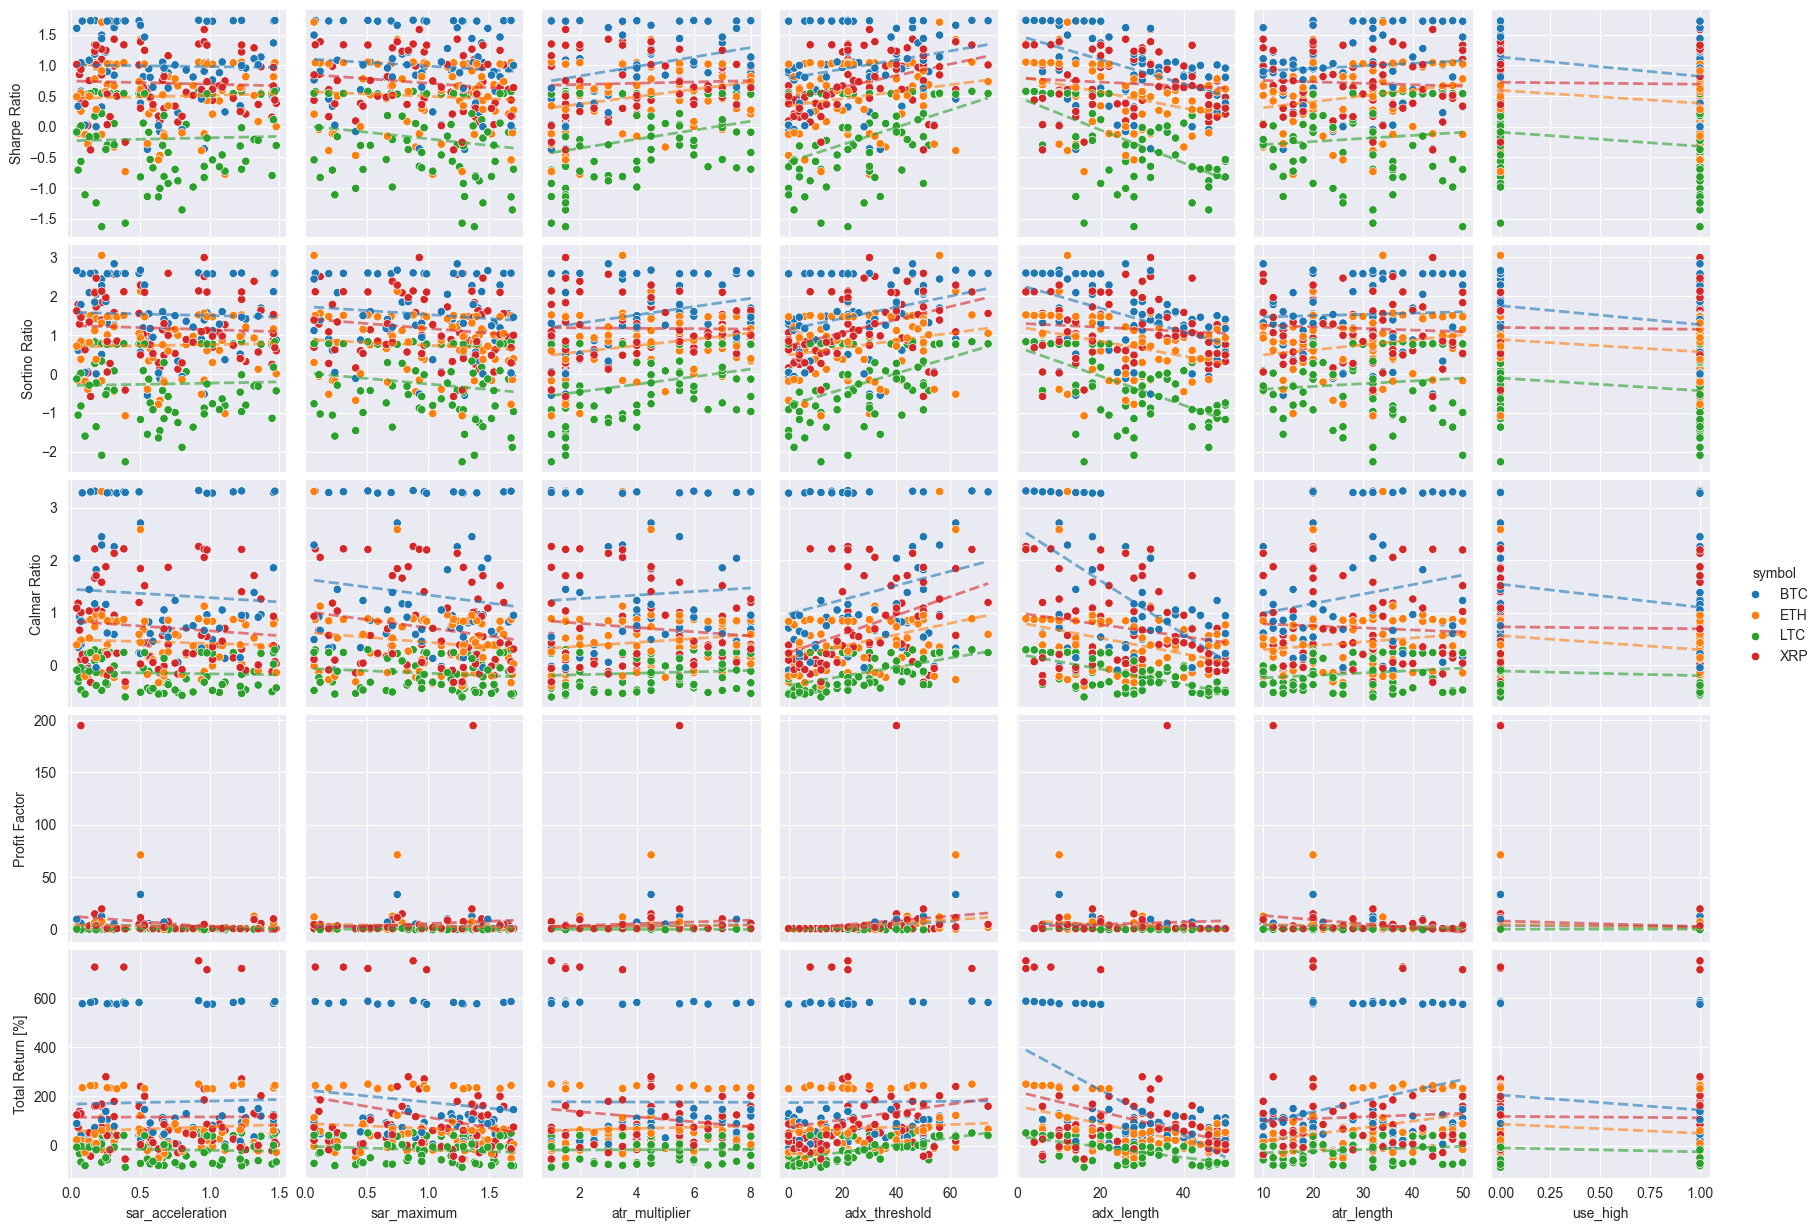

In [45]:

g = sns.pairplot(
    trials_summary,
    x_vars=parameters,
    y_vars=performance,
    hue="symbol",

)
for i, y in enumerate(performance):
    for j, x in enumerate(parameters):
        ax = g.axes[i, j]
        for sym, subdf in trials_summary.groupby("symbol"):
            sns.regplot(
                data=subdf,
                x=x,
                y=y,
                scatter=False,
                ci=None,
                ax=ax,
                label=sym,
                line_kws={
                    "linestyle": "--",  # dashed line
                    "alpha": 0.6,  # transparency
                    "lw": 2,  # line width
                },
            )




## Part2: Further exploration

Set defaults for values that dont seem to correlate well:
- use_high = False


In [46]:
def objective(trial: optuna.Trial):
    # Entry
    params['adx_threshold'] = trial.suggest_int("adx_threshold", 10, 50, step=2)  #
    params['adx_length'] = trial.suggest_int("adx_length", 2, 50, step=2)
    # params['sar_acceleration'] = trial.suggest_float("sar_acceleration", 0.08, 1.5, step=0.01)
    # params['sar_maximum'] = trial.suggest_float("sar_maximum", 0.07, 1.7, step=0.01)

    # Exit
    params['atr_multiplier'] = trial.suggest_float("atr_multiplier", 1, 8, step=0.5)
    params['atr_length'] = trial.suggest_int("atr_length", 2, 50, step=2)
    # params['use_high'] = trial.suggest_categorical("use_high", [True, False])

    entries, exits, sl_stop = calc_signals(close, high, low, **params)

    pf = vbt.Portfolio.from_signals(close,
                                    entries=entries,
                                    exits=exits,
                                    size=1,
                                    size_type='percent',
                                    direction='longonly',
                                    sl_stop=sl_stop,
                                    sl_trail=True,
                                    freq=interval,
                                    fees=transaction_fee,
                                    init_cash=start_equity,
                                    )
    stats_df = pd.DataFrame({col: pf[col].stats() for col in pf.wrapper.columns})
    sharpe = stats_df.loc["Sharpe Ratio"].mean()

    if sharpe is None or math.isnan(sharpe) or math.isinf(sharpe):
        raise optuna.exceptions.TrialPruned("Invalid objective (NaN/Inf).")
    wide = stats_df_to_wide(stats_df, trial.number)
    params_df = pd.DataFrame(params, index=wide.index)
    trial_summary = pd.concat([wide, params_df], axis=1)
    trials_summary_list.append(trial_summary)

    return sharpe


trials_summary_list = []
# reset params
params = params_default.copy()
study2 = optuna.create_study(direction="maximize", sampler=sampler)
study2.optimize(objective, n_trials=n_trials)
trials_summary2 = pd.concat(trials_summary_list, axis=0).reset_index(drop=True)

[I 2025-11-09 17:02:00,316] A new study created in memory with name: no-name-916b0d76-6db8-4b97-8c1d-0327fcf5b166
[I 2025-11-09 17:02:01,123] Trial 0 finished with value: 0.9829480626633772 and parameters: {'adx_threshold': 38, 'adx_length': 8, 'atr_multiplier': 5.0, 'atr_length': 32}. Best is trial 0 with value: 0.9829480626633772.
[I 2025-11-09 17:02:01,901] Trial 1 finished with value: 0.40335287461005304 and parameters: {'adx_threshold': 26, 'adx_length': 38, 'atr_multiplier': 8.0, 'atr_length': 48}. Best is trial 0 with value: 0.9829480626633772.
[I 2025-11-09 17:02:02,664] Trial 2 finished with value: 1.1627234036750917 and parameters: {'adx_threshold': 28, 'adx_length': 6, 'atr_multiplier': 8.0, 'atr_length': 42}. Best is trial 2 with value: 1.1627234036750917.
[I 2025-11-09 17:02:03,949] Trial 3 finished with value: 0.4178070041574337 and parameters: {'adx_threshold': 14, 'adx_length': 48, 'atr_multiplier': 7.5, 'atr_length': 26}. Best is trial 2 with value: 1.1627234036750917.

In [47]:
best_params2 = study2.best_params
best_value2 = study2.best_value
print(f"\nBest --> Sharpe: {best_value2:.2f} ")
print(tabulate(best_params2.items(), tablefmt="github"))


Best --> Sharpe: 1.18 
|----------------|----|
| adx_threshold  | 18 |
| adx_length     |  2 |
| atr_multiplier |  2 |
| atr_length     | 30 |


In [48]:
print(f"\nTop 10% Trials Summary:")
parameters = list(best_params2.keys())
cols = parameters + performance
top_10_pct = int(n_trials * 0.1)
top_runs = trials_summary2.sort_values('Sharpe Ratio', ascending=False).groupby('symbol').head(top_10_pct)
print(f"\nPer symbol:")
print(top_runs.groupby('symbol')[cols].describe())
print(f"\nAcross all symbols:")
print(top_runs[cols].describe())


Top 10% Trials Summary:

Per symbol:
       adx_threshold                                                 \
               count  mean        std   min   25%   50%   75%   max   
symbol                                                                
BTC             10.0  31.8  13.612086  10.0  20.0  32.0  45.0  48.0   
ETH             10.0  36.6  13.696715  10.0  29.5  42.0  45.5  50.0   
LTC             10.0  32.2  14.124840  10.0  20.0  32.0  45.0  50.0   
XRP             10.0  33.4  12.825322  10.0  25.5  36.0  43.5  50.0   

       adx_length        ... Profit Factor            Total Return [%]  \
            count  mean  ...           75%        max            count   
symbol                   ...                                             
BTC          10.0   4.8  ...           NaN        NaN             10.0   
ETH          10.0   7.6  ...      4.415497   4.934638             10.0   
LTC          10.0   3.4  ...           NaN        NaN             10.0   
XRP          10.0  2

In [49]:
fig3 = optuna.visualization.plot_param_importances(study2)
show(fig3)

# fig4 = optuna.visualization.plot_slice(study2, params=best_params2.keys())
# show(fig4)


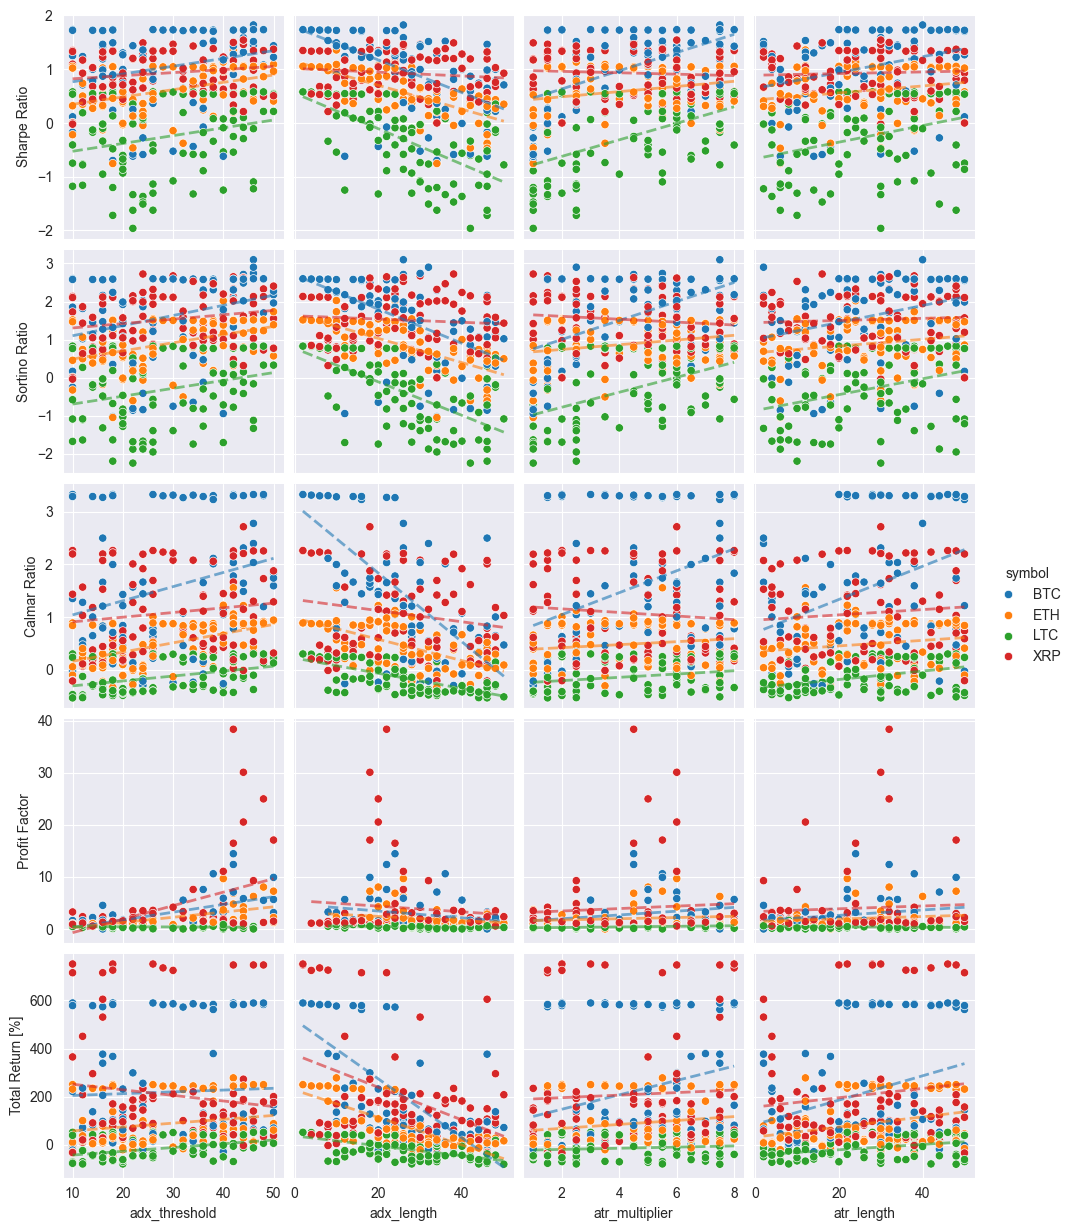

In [50]:
parameters = list(best_params2.keys())
performance = ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio', 'Profit Factor', 'Total Return [%]']
g2 = sns.pairplot(
    trials_summary2,
    x_vars=parameters,
    y_vars=performance,
    hue="symbol",

)
for i, y in enumerate(performance):
    for j, x in enumerate(parameters):
        ax = g2.axes[i, j]
        for sym, subdf in trials_summary2.groupby("symbol"):
            sns.regplot(
                data=subdf,
                x=x,
                y=y,
                scatter=False,
                ci=None,
                ax=ax,
                label=sym,
                line_kws={
                    "linestyle": "--",  # dashed line
                    "alpha": 0.6,  # transparency
                    "lw": 2,  # line width
                },
            )




### All Symbols

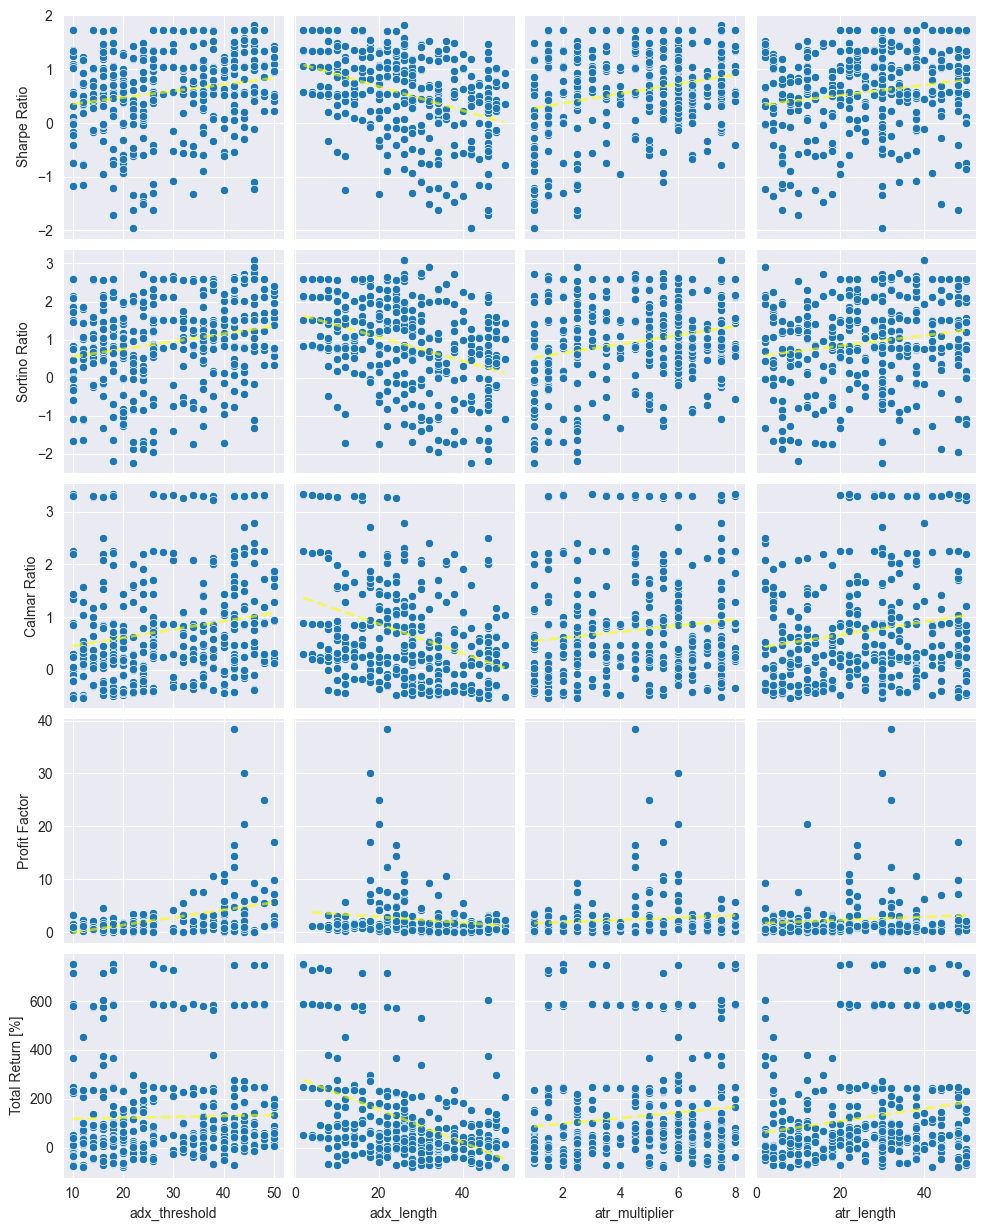

In [51]:
g3 = sns.pairplot(
    trials_summary2,
    x_vars=parameters,
    y_vars=performance,

)
for i, y in enumerate(performance):
    for j, x in enumerate(parameters):
        ax = g3.axes[i, j]
        sns.regplot(
            data=trials_summary2,
            x=x,
            y=y,
            scatter=False,
            ci=None,
            ax=ax,

            line_kws={
                "linestyle": "--",  # dashed line
                "alpha": 0.6,  # transparency
                "lw": 2,  # line width
                "color": "yellow",
            },
        )


## Part 3: Final Results

In [52]:
def objective(trial: optuna.Trial):
    # Entry
    params['adx_threshold'] = trial.suggest_int("adx_threshold", 25, 45, step=1)  #
    params['adx_length'] = trial.suggest_int("adx_length", 10, 25, step=1)
    # params['sar_acceleration'] = trial.suggest_float("sar_acceleration", 0.08, 1.5, step=0.01)
    # params['sar_maximum'] = trial.suggest_float("sar_maximum", 0.07, 1.7, step=0.01)

    # Exit
    params['atr_multiplier'] = trial.suggest_float("atr_multiplier", 3, 8, step=0.5)
    params['atr_length'] = trial.suggest_int("atr_length", 14, 40, step=1)
    # params['use_high'] = trial.suggest_categorical("use_high", [True, False])

    entries, exits, sl_stop = calc_signals(close, high, low, **params)

    pf = vbt.Portfolio.from_signals(close,
                                    entries=entries,
                                    exits=exits,
                                    size=1,
                                    size_type='percent',
                                    direction='longonly',
                                    sl_stop=sl_stop,
                                    sl_trail=True,
                                    freq=interval,
                                    fees=transaction_fee,
                                    init_cash=start_equity,
                                    )
    stats_df = pd.DataFrame({col: pf[col].stats() for col in pf.wrapper.columns})
    sharpe = stats_df.loc["Sharpe Ratio"].mean()

    if sharpe is None or math.isnan(sharpe) or math.isinf(sharpe):
        print(params)
        raise optuna.exceptions.TrialPruned("Invalid objective (NaN/Inf).")
    wide = stats_df_to_wide(stats_df, trial.number)
    params_df = pd.DataFrame(params, index=wide.index)
    trial_summary = pd.concat([wide, params_df], axis=1)
    trials_summary_list.append(trial_summary)

    return sharpe


trials_summary_list = []
# reset params
params = params_default.copy()
study3 = optuna.create_study(direction="maximize", sampler=sampler)
study3.optimize(objective, n_trials=n_trials)
trials_summary3 = pd.concat(trials_summary_list, axis=0).reset_index(drop=True)

[I 2025-11-09 17:03:22,474] A new study created in memory with name: no-name-1befe06d-90c0-489c-b72b-8766e7cc6cdb
[I 2025-11-09 17:03:23,598] Trial 0 finished with value: 0.529273330094809 and parameters: {'adx_threshold': 40, 'adx_length': 10, 'atr_multiplier': 3.0, 'atr_length': 22}. Best is trial 0 with value: 0.529273330094809.
[I 2025-11-09 17:03:24,222] Trial 1 finished with value: 0.7100384561255022 and parameters: {'adx_threshold': 35, 'adx_length': 22, 'atr_multiplier': 6.5, 'atr_length': 26}. Best is trial 1 with value: 0.7100384561255022.
[I 2025-11-09 17:03:24,854] Trial 2 finished with value: 0.5377331553859411 and parameters: {'adx_threshold': 30, 'adx_length': 25, 'atr_multiplier': 5.0, 'atr_length': 26}. Best is trial 1 with value: 0.7100384561255022.
[I 2025-11-09 17:03:25,484] Trial 3 finished with value: 0.5259293060752135 and parameters: {'adx_threshold': 28, 'adx_length': 22, 'atr_multiplier': 6.5, 'atr_length': 19}. Best is trial 1 with value: 0.7100384561255022.


In [53]:
best_params3 = study3.best_params
best_value3 = study3.best_value
print(f"\nBest --> Sharpe: {best_value3:.2f} ")
print(tabulate(best_params3.items(), tablefmt="github"))


Best --> Sharpe: 1.06 
|----------------|----|
| adx_threshold  | 43 |
| adx_length     | 19 |
| atr_multiplier |  3 |
| atr_length     | 39 |


In [54]:
print(f"\nTop 10% Trials Summary:")
parameters = list(best_params3.keys())
cols = parameters + performance
top_10_pct = int(n_trials * 0.1)
top_runs = trials_summary3.sort_values('Sharpe Ratio', ascending=False).groupby('symbol').head(top_10_pct)
print(f"\nPer symbol:")
print(top_runs.groupby('symbol')[cols].describe())
print(f"\nAcross all symbols:")
print(top_runs[cols].describe())

# nan values?

print(f"\nBot 10% Trials Summary:")
bot_runs = trials_summary3.sort_values('Sharpe Ratio', ascending=True).groupby('symbol').head(top_10_pct)
print(f"\nAcross all symbols:")
print(bot_runs[cols].describe())

# final look

print(trials_summary.info())

# Why are some Profit factor NaN or inf


Top 10% Trials Summary:

Per symbol:
       adx_threshold                                                  \
               count  mean       std   min    25%   50%    75%   max   
symbol                                                                 
BTC             10.0  30.0  5.981453  25.0  27.00  28.0  29.75  44.0   
ETH             10.0  36.1  5.087021  28.0  33.25  36.5  39.00  45.0   
LTC             10.0  34.5  8.058812  25.0  27.25  33.0  42.25  45.0   
XRP             10.0  39.7  4.922736  31.0  37.25  40.5  43.75  45.0   

       adx_length        ... Profit Factor            Total Return [%]  \
            count  mean  ...           75%        max            count   
symbol                   ...                                             
BTC          10.0  12.3  ...      6.697135   6.697135             10.0   
ETH          10.0  17.5  ...      3.488584  14.314786             10.0   
LTC          10.0  11.9  ...           NaN        NaN             10.0   
XRP          

In [55]:
fig5 = optuna.visualization.plot_param_importances(study3)
show(fig5)


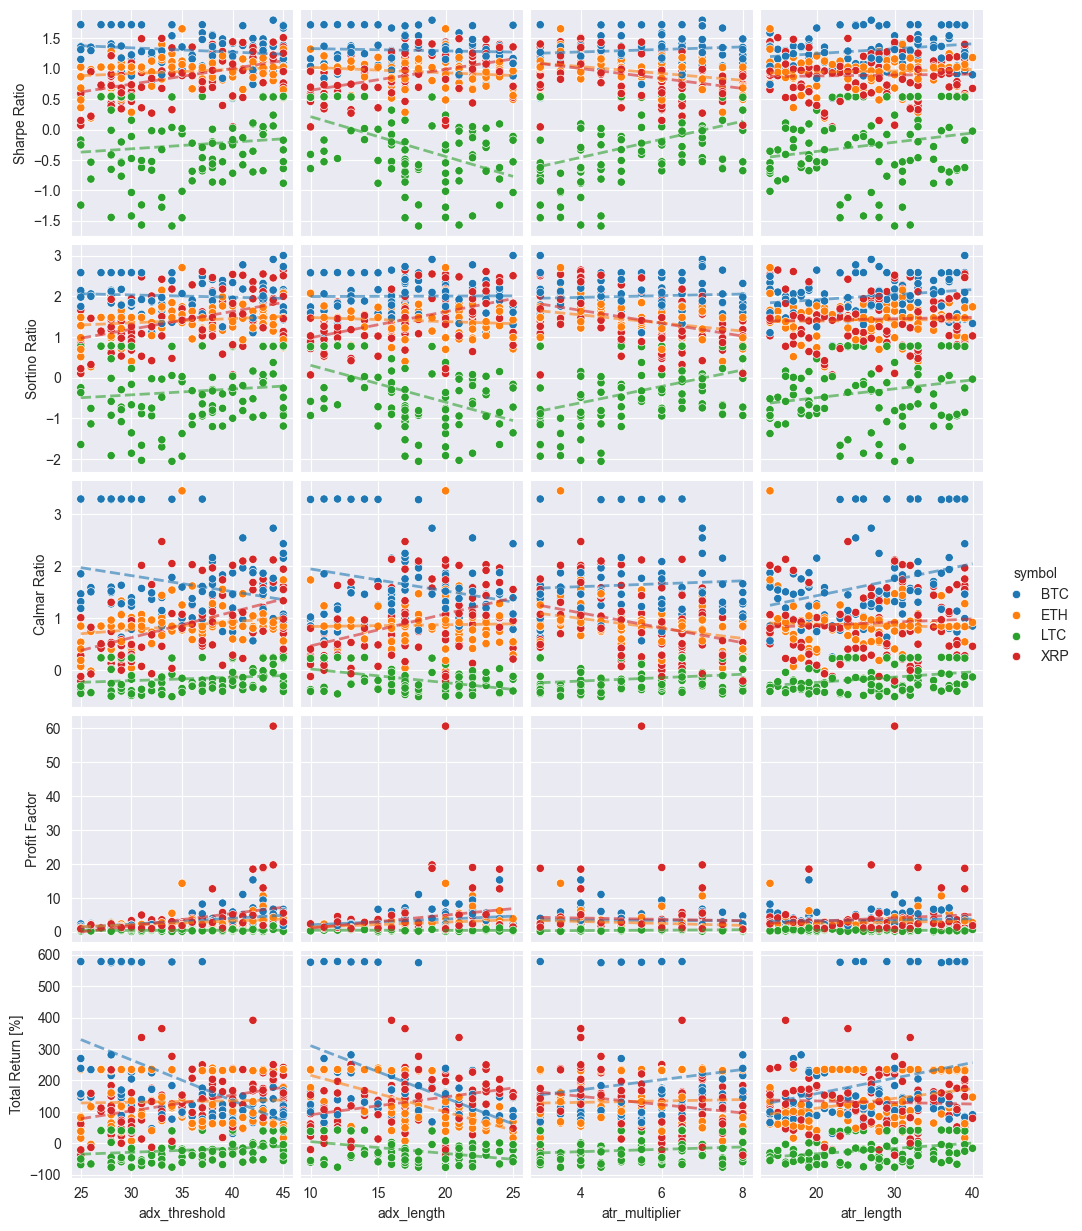

In [56]:
parameters = list(best_params3.keys())
performance = ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio', 'Profit Factor', 'Total Return [%]']
g4 = sns.pairplot(
    trials_summary3,
    x_vars=parameters,
    y_vars=performance,
    hue="symbol",

)
for i, y in enumerate(performance):
    for j, x in enumerate(parameters):
        ax = g4.axes[i, j]
        for sym, subdf in trials_summary3.groupby("symbol"):
            sns.regplot(
                data=subdf,
                x=x,
                y=y,
                scatter=False,
                ci=None,
                ax=ax,
                label=sym,
                line_kws={
                    "linestyle": "--",  # dashed line
                    "alpha": 0.6,  # transparency
                    "lw": 2,  # line width
                },
            )




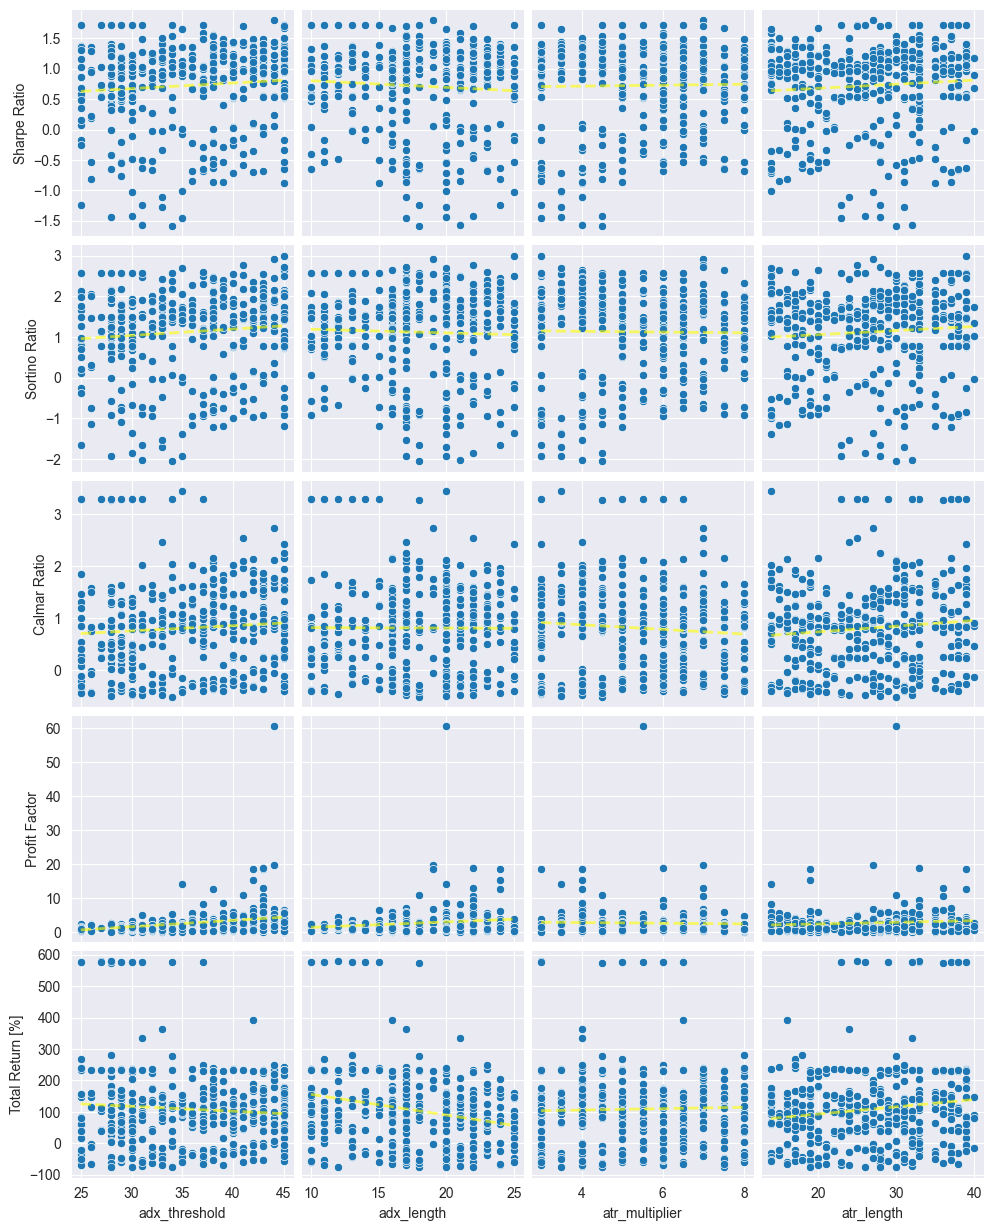

In [57]:
g5 = sns.pairplot(
    trials_summary3,
    x_vars=parameters,
    y_vars=performance,

)
for i, y in enumerate(performance):
    for j, x in enumerate(parameters):
        ax = g5.axes[i, j]
        sns.regplot(
            data=trials_summary3,
            x=x,
            y=y,
            scatter=False,
            ci=None,
            ax=ax,

            line_kws={
                "linestyle": "--",  # dashed line
                "alpha": 0.6,  # transparency
                "lw": 2,  # line width
                "color": "yellow",
            },
        )


### Final Parameter Search Space

In [58]:
params_default = {'sar_acceleration': 0.02,  # little correlation
                  'sar_maximum': 0.2,  # has little correlation
                  'adx_threshold': [25, 45],  # higher adx_thresholds can result in no trades being executed
                  'adx_length': [14, 25],  # for entry
                  'atr_multiplier': [2, 6],  # for exit
                  'atr_length': [14, 25],  # atr multiplier for  exit
                  'use_high': False,
                  }




## Part 4: Extra, hmm but what does Optuna think is best?

I'll use the default search space and let Optuna explore the space and find the best parameters.

In [65]:
def objective(trial: optuna.Trial):
    # Entry
    params['adx_threshold'] = trial.suggest_int("adx_threshold", 10, 46, step=2)  #
    params['adx_length'] = trial.suggest_int("adx_length", 10, 50, step=2)
    # params['sar_acceleration'] = trial.suggest_float("sar_acceleration", 0.02, 1.5, step=0.01)
    # params['sar_maximum'] = trial.suggest_float("sar_maximum", 0.05, 1.7, step=0.01)

    # Exit
    params['atr_multiplier'] = trial.suggest_float("atr_multiplier", 1, 8, step=0.5)
    params['atr_length'] = trial.suggest_int("atr_length", 10, 50, step=2)
    # params['use_high'] = trial.suggest_categorical("use_high", [True, False])

    entries, exits, sl_stop = calc_signals(close, high, low, **params)

    pf = vbt.Portfolio.from_signals(close,
                                    entries=entries,
                                    exits=exits,
                                    size=1,
                                    size_type='percent',
                                    direction='longonly',
                                    sl_stop=sl_stop,
                                    sl_trail=True,
                                    freq=interval,
                                    fees=transaction_fee,
                                    init_cash=start_equity,
                                    )
    stats_df = pd.DataFrame({col: pf[col].stats() for col in pf.wrapper.columns})
    sharpe = stats_df.loc["Sharpe Ratio"].mean()

    if sharpe is None or math.isnan(sharpe) or math.isinf(sharpe):
        raise optuna.exceptions.TrialPruned("Invalid objective (NaN/Inf).")
    wide = stats_df_to_wide(stats_df, trial.number)
    params_df = pd.DataFrame(params, index=wide.index)
    trial_summary = pd.concat([wide, params_df], axis=1)
    trials_summary_list.append(trial_summary)

    return sharpe


trials_summary_list = []
params = params_default.copy()
study_opt = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study_opt.optimize(objective, n_trials=n_trials)
trials_summary_opt = pd.concat(trials_summary_list, axis=0).reset_index(drop=True)

[I 2025-11-09 17:11:42,803] A new study created in memory with name: no-name-dab81a33-86d1-4fb6-b706-a8da1750dfb8
[I 2025-11-09 17:11:43,447] Trial 0 finished with value: 0.34535863247450577 and parameters: {'adx_threshold': 24, 'adx_length': 48, 'atr_multiplier': 6.0, 'atr_length': 34}. Best is trial 0 with value: 0.34535863247450577.
[I 2025-11-09 17:11:44,502] Trial 1 finished with value: 0.7013998626574096 and parameters: {'adx_threshold': 14, 'adx_length': 16, 'atr_multiplier': 1.0, 'atr_length': 46}. Best is trial 1 with value: 0.7013998626574096.
[I 2025-11-09 17:11:45,127] Trial 2 finished with value: -0.07871439660265156 and parameters: {'adx_threshold': 32, 'adx_length': 38, 'atr_multiplier': 1.0, 'atr_length': 50}. Best is trial 1 with value: 0.7013998626574096.
[I 2025-11-09 17:11:45,752] Trial 3 finished with value: 0.6543036286031738 and parameters: {'adx_threshold': 40, 'adx_length': 18, 'atr_multiplier': 2.0, 'atr_length': 16}. Best is trial 1 with value: 0.701399862657

In [66]:
trials = study_opt.trials_dataframe()
trials.sort_values('value', inplace=True, ascending=False)
trials.columns = trials.columns.str.removeprefix('params_')
trials.drop(['datetime_start', 'datetime_complete', 'duration', 'state'], axis=1, inplace=True)
print(tabulate(trials, headers='keys', tablefmt='github', showindex=False))



|   number |      value |   adx_length |   adx_threshold |   atr_length |   atr_multiplier |
|----------|------------|--------------|-----------------|--------------|------------------|
|       32 |  1.15903   |           12 |              12 |           46 |              7.5 |
|       35 |  1.15903   |           12 |              12 |           48 |              6.5 |
|       60 |  1.15903   |           12 |              16 |           42 |              7   |
|       45 |  1.15903   |           12 |              14 |           42 |              1.5 |
|       71 |  1.15903   |           12 |              16 |           42 |              7   |
|       75 |  1.15903   |           12 |              16 |           46 |              7   |
|       80 |  1.15903   |           12 |              10 |           48 |              8   |
|       81 |  1.15903   |           12 |              10 |           46 |              8   |
|       92 |  1.15903   |           12 |              12 |           4

In [61]:
parameters = list(params.keys())
performance = ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio', 'Profit Factor', 'Total Return [%]']

print(f"\nTop 10% Trials Summary:")
cols = parameters + performance
top_10_pct = int(n_trials * 0.1)
top_runs = trials_summary_opt.sort_values('Sharpe Ratio', ascending=False).groupby('symbol').head(top_10_pct)
print(f"\nPer symbol:")
print(top_runs.groupby('symbol')[cols].describe())
print(f"\nAcross all symbols:")
print(top_runs[cols].describe())

best_params = study.best_params
best_value = study.best_value
print(f"\nBest --> Sharpe: {best_value:.2f} ")
print(tabulate(best_params.items(), tablefmt="github"))


Top 10% Trials Summary:

Per symbol:
       sar_acceleration                                                    \
                  count   mean       std   min    25%   50%     75%   max   
symbol                                                                      
BTC                10.0  0.661  0.135355  0.48  0.540  0.67  0.7900  0.80   
ETH                10.0  0.607  0.340198  0.16  0.420  0.57  0.6975  1.41   
LTC                10.0  0.604  0.136398  0.41  0.505  0.58  0.7200  0.80   
XRP                10.0  0.709  0.384114  0.16  0.475  0.67  0.8000  1.41   

       sar_maximum         ... Profit Factor            Total Return [%]  \
             count   mean  ...           75%        max            count   
symbol                     ...                                             
BTC           10.0  1.092  ...           NaN        NaN             10.0   
ETH           10.0  0.400  ...     13.284694  73.399640             10.0   
LTC           10.0  0.694  ...           N

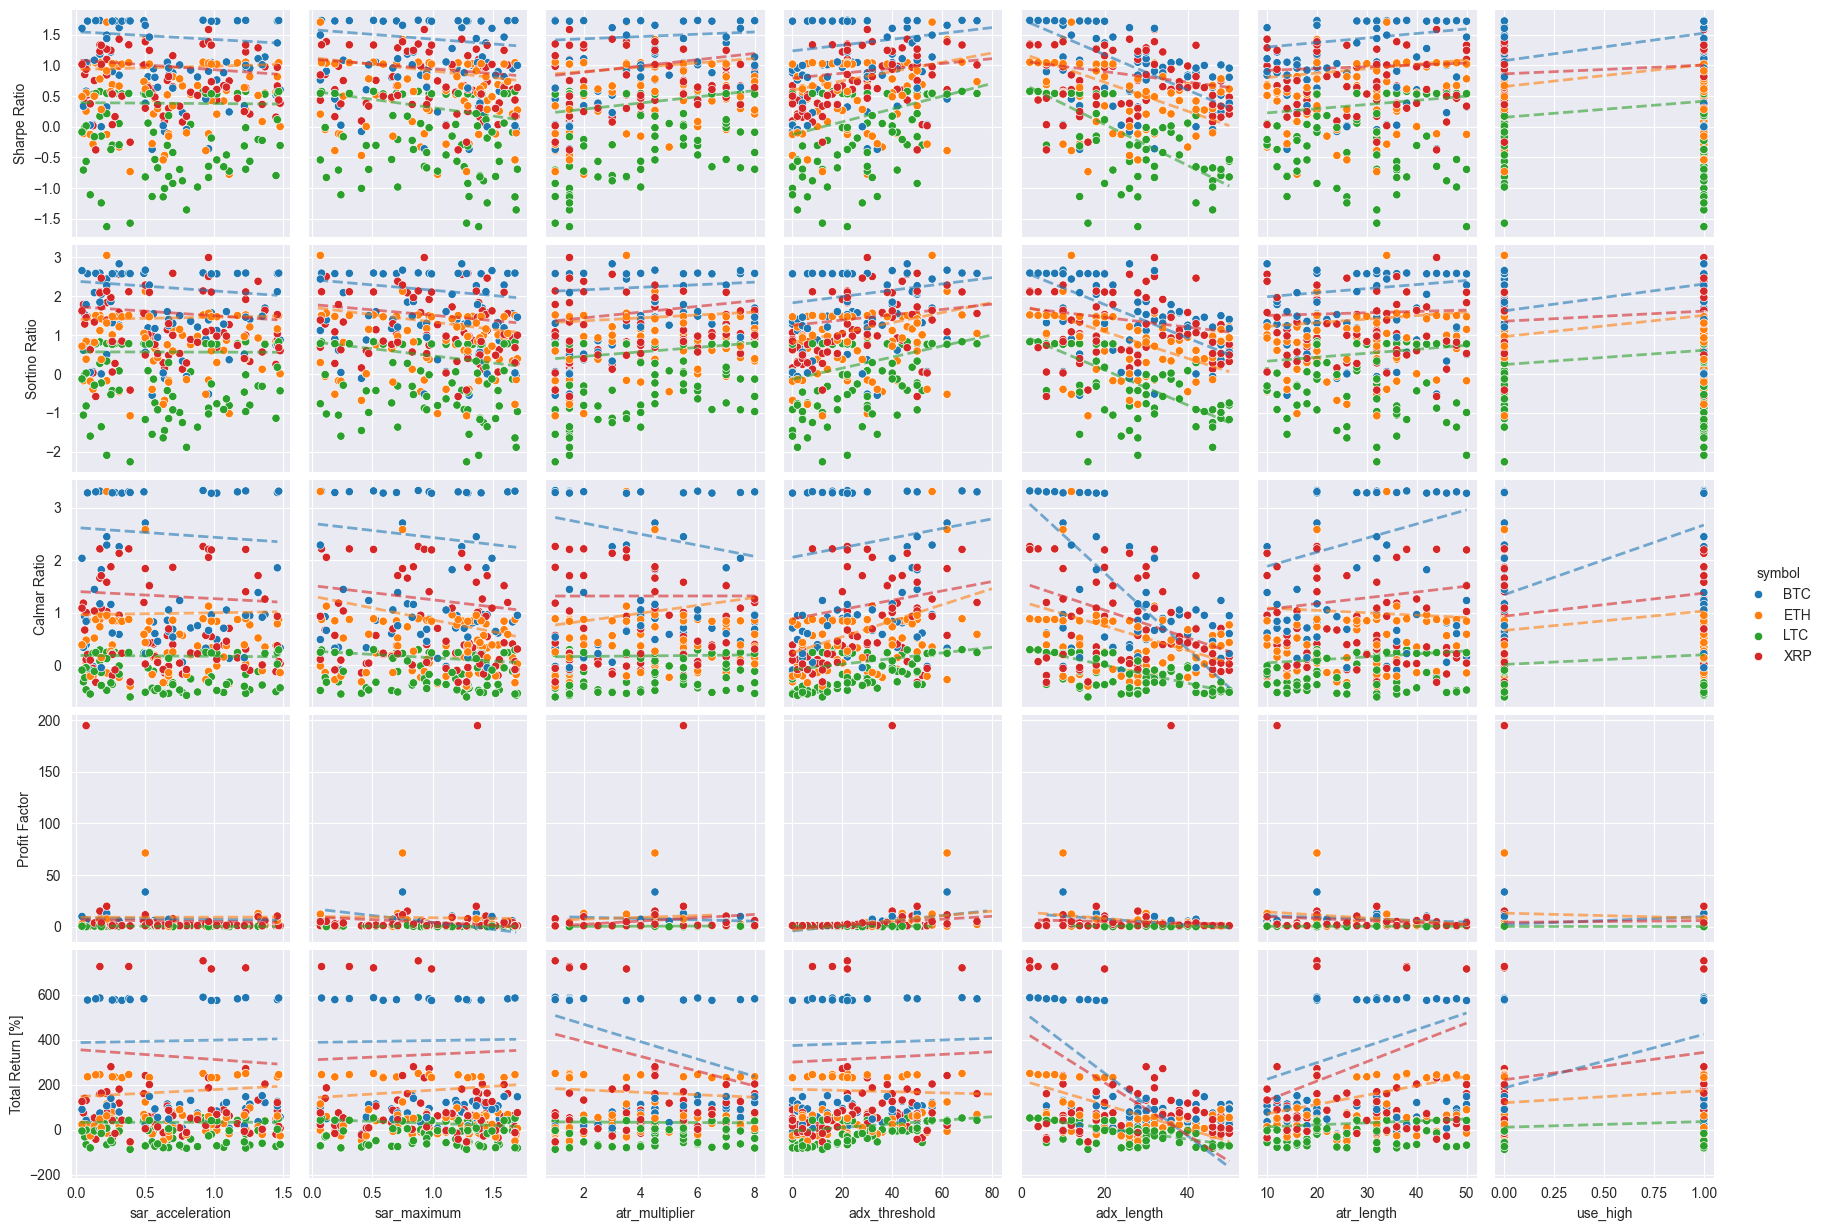

In [62]:
fig_opt = optuna.visualization.plot_param_importances(study_opt)
show(fig_opt)
fig_opt1 = optuna.visualization.plot_optimization_history(study_opt)
show(fig_opt1)
fig_opt2 = optuna.visualization.plot_slice(study_opt)
show(fig_opt2)

g_opt = sns.pairplot(
    trials_summary,
    x_vars=parameters,
    y_vars=performance,
    hue="symbol",

)
for i, y in enumerate(performance):
    for j, x in enumerate(parameters):
        ax = g_opt.axes[i, j]
        for sym, subdf in trials_summary_opt.groupby("symbol"):
            sns.regplot(
                data=subdf,
                x=x,
                y=y,
                scatter=False,
                ci=None,
                ax=ax,
                label=sym,
                line_kws={
                    "linestyle": "--",  # dashed line
                    "alpha": 0.6,  # transparency
                    "lw": 2,  # line width
                },
            )


